In [1]:
import os

import sklearn.model_selection
from model import *
from plotting import *
from dataset import *
from tokenization import *
from translation import *
from colorama import Fore, Style

import tomllib

import sentencepiece as spm

import click

import matplotlib.pyplot as plt

from datasets import load_dataset

from tqdm import tqdm

import polars as pl

import sklearn
import traceback
import time
import random

In [2]:
with open('config_te.toml', 'rb') as f:
    config = tomllib.load(f)

print(config)

{'data_root': './data_te', 'model': {'max_context': 512, 'd_model': 512, 'd_ff': 2048, 'h': 8, 'N': 6}, 'tokenizer': {'max_sentence_length': 16384, 'input_sentence_size': 400000, 'source_vocab_size': 49152, 'target_vocab_size': 32767, 'start_id': 1, 'end_id': 2, 'pad_id': 0, 'unk_id': 3}, 'training': {'save_every': 1000, 'batch_size': 32, 'epochs': 10, 'lr': 0.0001}, 'data': {'test_split': 0.02}}


In [3]:
sp_source = spm.SentencePieceProcessor(model_file=f"{config['data_root']}/tokenizers/source.model")
sp_target = spm.SentencePieceProcessor(model_file=f"{config['data_root']}/tokenizers/target.model")

transformer = Transformer(config["model"]["d_model"],
                        config["model"]["d_ff"],
                        config["model"]["h"],
                        sp_source.GetPieceSize(),
                        sp_target.GetPieceSize(),
                        config["model"]["N"],
                        config["model"]["max_context"])
model = "./data_te3/checkpoints/9_checkpoint.pth"
model = "./test2.pth"
if model is not None:
        checkpoint = torch.load(model, map_location=torch.device("cpu"), weights_only=True)
        transformer.load_state_dict(checkpoint["model_state_dict"])

translator = Translator(transformer, sp_source, sp_target)

In [4]:
from torchinfo import summary
summary(translator.transformer)

Layer (type:depth-idx)                        Param #
Transformer                                   --
├─Encoder: 1-1                                --
│    └─Embedding: 2-1                         25,165,824
│    └─PositionalEncoding: 2-2                --
│    └─ModuleList: 2-3                        --
│    │    └─EncoderLayer: 3-1                 3,152,384
│    │    └─EncoderLayer: 3-2                 3,152,384
│    │    └─EncoderLayer: 3-3                 3,152,384
│    │    └─EncoderLayer: 3-4                 3,152,384
│    │    └─EncoderLayer: 3-5                 3,152,384
│    │    └─EncoderLayer: 3-6                 3,152,384
├─Decoder: 1-2                                --
│    └─Embedding: 2-4                         16,776,704
│    └─PositionalEncoding: 2-5                --
│    └─ModuleList: 2-6                        --
│    │    └─DecoderLayer: 3-7                 4,204,032
│    │    └─DecoderLayer: 3-8                 4,204,032
│    │    └─DecoderLayer: 3-9            

In [10]:
translator.inference("బంగాళాదుంపలు ఎక్కడ ఉన్నాయి?")

'Where are the bananas?'

In [6]:
def get_token_array(tokenizer, string, add_bos=False, add_eos=False):
    token_ids = tokenizer.encode_as_ids(string, add_bos=add_bos, add_eos=add_eos)
    return [tokenizer.decode_ids(x) for x in token_ids]

tokens_in = get_token_array(sp_source, "నాకు దగ్గర్లోని రెస్టారెంట్ ఎక్కడ దొరుకుతుంది?")

In [7]:
transliterate(es_test, sanscript.TELUGU, sanscript.IAST)

NameError: name 'transliterate' is not defined

In [8]:
import nltk

# es_test = "సంవత్సరానికి ఎన్నిసార్లు మీరు స్కీయింగ్‌కు వెళతారు?"
en_test = "I love you."
es_tokens = torch.LongTensor(sp_source.encode_as_ids(es_test, add_bos=True, add_eos=True))
es_tokens = es_tokens.unsqueeze(0)
en_tokens = torch.LongTensor(sp_target.encode_as_ids(en_test))
en_tokens = en_tokens.unsqueeze(0)
print(es_tokens, en_tokens)

output = transformer.forward(en_tokens, es_tokens)
output = torch.argmax(output, dim=-1)
print([sp_target.decode_ids(x) for x in en_tokens[0].tolist()])


predicted_tokens = torch.tensor([1])

for i in range(60):
    output = transformer.forward(predicted_tokens.unsqueeze(0), es_tokens)
    output = torch.argmax(output, dim=-1)
    predicted_tokens = torch.cat([predicted_tokens, output[0, -1].unsqueeze(0)])
    if (predicted_tokens[-1] == 2):
        break

print(predicted_tokens)
print([sp_source.Decode(x) for x in es_tokens[0].detach().numpy().tolist()])
print(sp_target.decode_ids(predicted_tokens.tolist()))

translation = sp_target.decode_ids(predicted_tokens.tolist())

print(translation.split(" "), en_test.split(" "))

BLEUscore = nltk.translate.bleu_score.sentence_bleu([en_test.split(" ")], translation.split(" "), weights=(1/3.,1/3.,1/3.))
print(BLEUscore)


tensor([[    1,  1916,   174, 10153,     8,  5965,   401,   162, 26676,    66,
             2]]) tensor([[ 34, 270,  50,   4]])
['I', 'love', 'you', '.']
tensor([   1,  137,   29,  974,  270,  191, 2760,   85,    2])
['', 'నువ్వు', 'నా', 'కళ్ళ', 'ను', 'సంతోష', 'ప', 'రు', 'స్తావు', '!', '']
You'll love my eye!
["You'll", 'love', 'my', 'eye!'] ['I', 'love', 'you.']
4.983597475548963e-206


/opt/conda/envs/ML/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/opt/conda/envs/ML/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


torch.Size([1, 8, 8, 11])
['', 'నువ్వు', 'నా', 'కళ్ళ', 'ను', 'సంతోష', 'ప', 'రు', 'స్తావు', '!', ''] ['', 'You', "'", 'll', 'love', 'my', 'eye', '!']
11 8


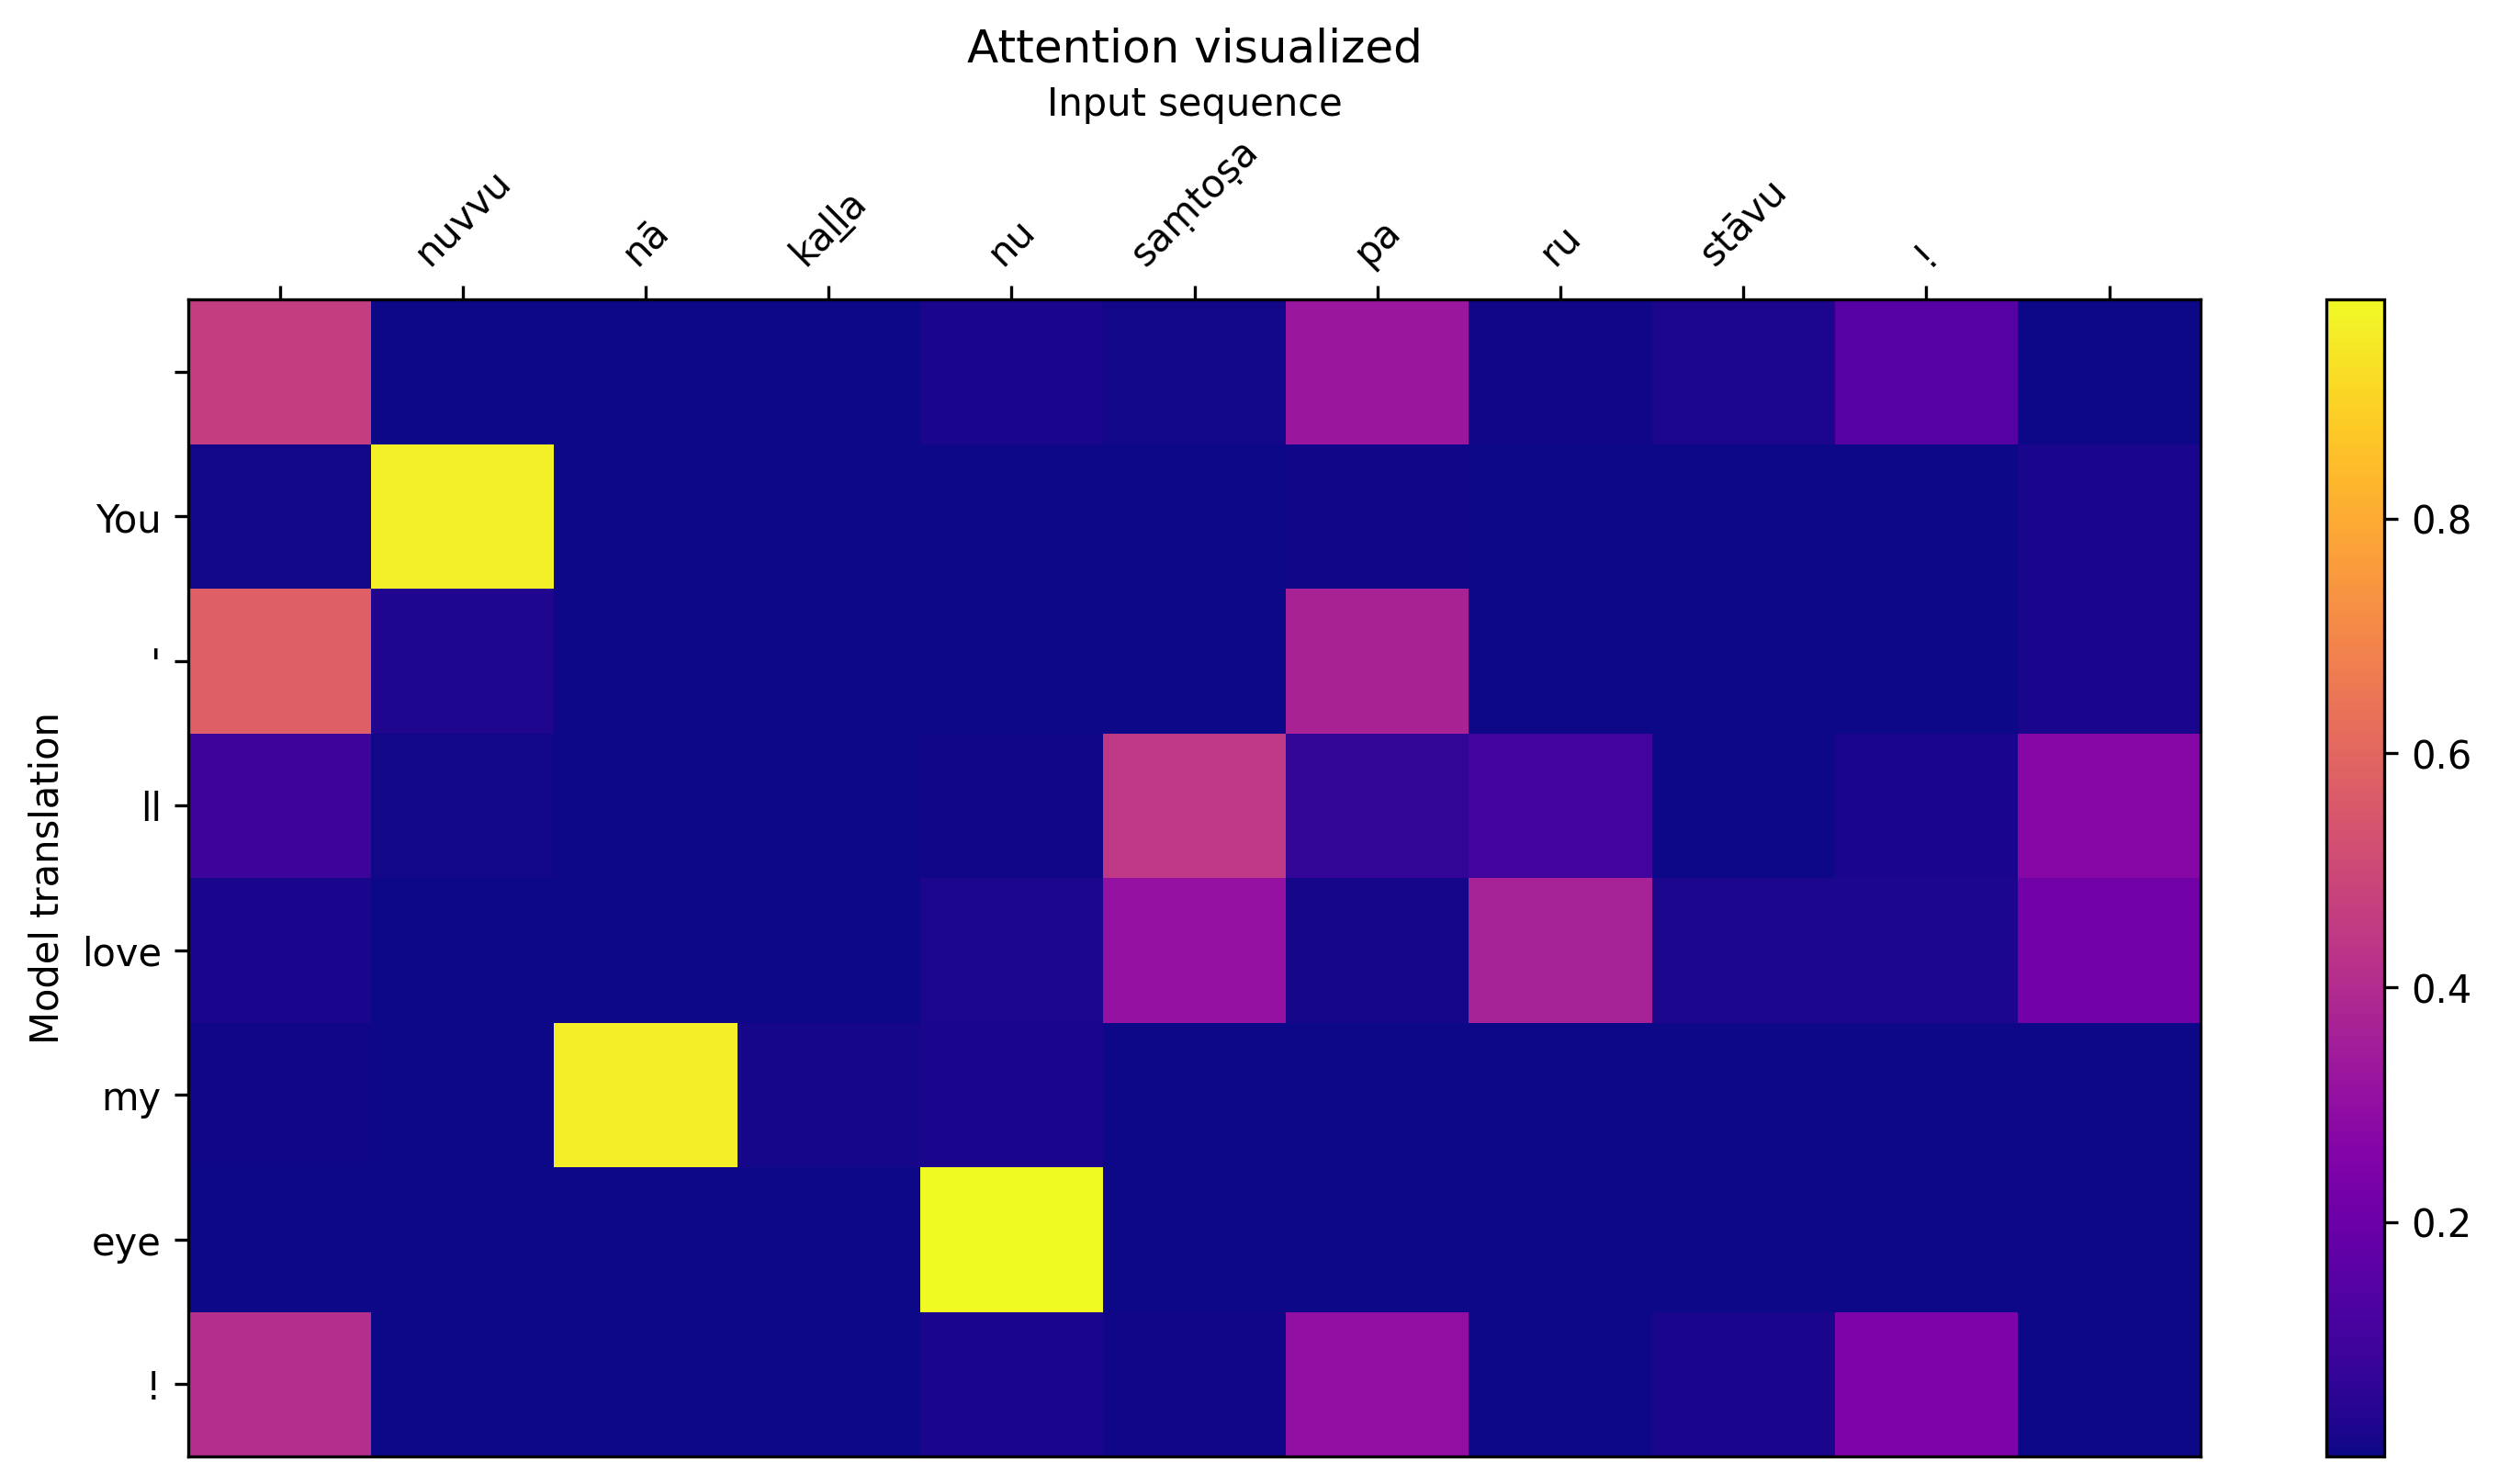

In [9]:
from pathlib import Path
from matplotlib.font_manager import FontProperties
from indic_transliteration import sanscript
from indic_transliteration.sanscript import SchemeMap, SCHEMES, transliterate

font_path = Path("./NotoSansTelugu_Condensed-Regular.ttf")
font = FontProperties(fname=font_path)

def plot_attention(file, attention, query_tokens=None, key_tokens=None):
    fig, ax = plt.subplots(figsize=(11, 6), dpi=300)
    fig.subplots_adjust(left=0.12, right=0.95, top=0.80, bottom=0.1)
    plot = ax.pcolormesh(attention, cmap='plasma')
    # plot = ax.pcolormesh(torch.softmax(mask[0], -1))
    ax.xaxis.set_ticks_position('top')
    # ax.set_xlabel("English"
    ax.set_xticks(np.arange(attention.shape[1]) + 0.5)
    if query_tokens:
        # ax.set_xticklabels(query_tokens, rotation=45, fontproperties=font)
        ax.set_xticklabels(query_tokens, rotation=45)
    else:
        ax.set_xticklabels(range(attention.shape[1]))
        

    # ax.set_yticklabels(tokenizer_en.encode(phrase_en).tokens)
    ax.set_yticks(np.arange(attention.shape[0]) + 0.5)
    if key_tokens:
        ax.set_yticklabels(key_tokens)
    else:
        ax.set_yticklabels(range(attention.shape[0]))

    ax.set_ylabel('Query Tokens')
    ax.set_xlabel('Key Tokens')

    ax.set_xlabel("Input sequence")
    ax.set_ylabel("Model translation")

    ax.set_title("Attention visualized")
    # plt.figtext(0.03, 0.03, f"Target translation = \"Delhi Assembly Elections: Polling on February 5, results on 8.. Why is BJP unable to win in Delhi?\"\ntranslation = \"{translation}\"", wrap=False, horizontalalignment='left', fontsize=10)
    # plt.figtext(0.03, 0.03, f"Target translation = \"I love you, Shravani.\"\ntranslation = \"{translation}\"", wrap=False, horizontalalignment='left', fontsize=10)

    # ax.invert_yaxis()

    # ax.set_xticklabels(tokenizer_te.encode(phrase_te).tokens, fontfamily="Kohinoor Telugu")
    ax.invert_yaxis()
    ax.xaxis.set_label_position('top')
    fig.colorbar(plot)

    # save to file
    plt.savefig(file)

attention = transformer.decoder.get_cross_attention_weights()
attention = torch.stack(attention)
print(attention[0].shape)

sp_source.SetDecodeExtraOptions("bos:eos")

query_tokens = [sp_source.Decode(x) for x in es_tokens[0].detach().numpy().tolist()]
#key_tokens = [sp_target.Decode(x) for x in en_tokens[0].detach().numpy().tolist()]
key_tokens = [sp_target.Decode(x) for x in predicted_tokens[:-1].detach().numpy().tolist()]

print(query_tokens, key_tokens)
print(len(query_tokens), len(key_tokens))

attention = attention.detach().numpy()


query_tokens = [transliterate(x, sanscript.TELUGU, sanscript.IAST) for x in query_tokens]

# plot_attention("attention.png", np.mean(attention[0], axis=1)[0], query_tokens, key_tokens)
plot_attention("attention7.png", attention[3][0][0], query_tokens, key_tokens)

# plot_attention("attention_bbc.png", np.max(attention, axis=(0, 2))[0], query_tokens, key_tokens)
# 

In [9]:
from indic_transliteration import sanscript
from indic_transliteration.sanscript import SchemeMap, SCHEMES, transliterate

data = 'నేను నిన్ను ప్రేమిస్తున్నాను'
print(transliterate(data, sanscript.TELUGU, sanscript.HK))

nenu ninnu premistunnAnu


In [56]:
transliterate("ఎం ఆన్ అమ్మ అన్న", sanscript.TELUGU, sanscript.roman.TITUS)

'ĕṃ ān amma anna'

In [53]:
print(sanscript.roman)

<module 'indic_transliteration.sanscript.schemes.roman' from '/opt/conda/envs/ML/lib/python3.12/site-packages/indic_transliteration/sanscript/schemes/roman.py'>
